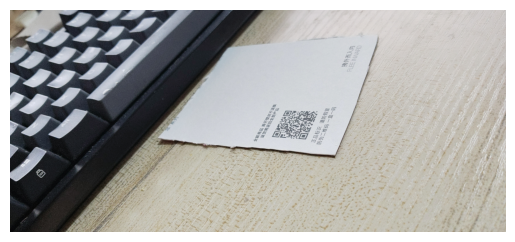

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("1766485014010.jpg")

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")  # 隐藏坐标轴
plt.show()

In [2]:
!pip install pyzbar

In [3]:
from pyzbar import pyzbar

decoded_objects = pyzbar.decode(image)

Decoded(data=b'https://104069.mark.toewin.com/?fwm=91089187096&b=105992&t=2', type='QRCODE', rect=Rect(left=1270, top=493, width=227, height=139), polygon=[Point(x=1270, y=620), Point(x=1435, y=632), Point(x=1497, y=497), Point(x=1338, y=493)], quality=1, orientation='LEFT')


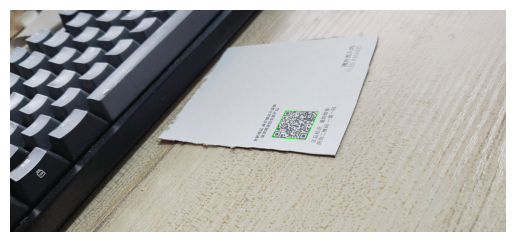

In [4]:
for obj in decoded_objects:
    print(obj)
    points = obj.polygon
    if len(points) > 0:
        pts = np.array(points, dtype=np.int32)
        cv2.polylines(image, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        data = obj.data.decode("utf-8")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")  # 隐藏坐标轴
plt.show()

In [5]:
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect


orig_height = image.shape[0]
orig_wid = image.shape[1]
pts = np.array(decoded_objects[0].polygon)
rect = order_points(pts)
(tl, tr, br, bl) = rect

widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))

matrix = [
    [int(max(tl)), int(min(tl))],
    [int(max(tl)) + int(widthB) - 1, int(min(tl))],
    [int(max(tl)) + int(widthB) - 1, int(min(tl)) + int(widthB) - 1],
    [int(max(tl)), int(min(tl)) + int(widthB) - 1],
]

dst = np.array(matrix, dtype="float32")

M = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(src=image, M=M, dsize=(orig_wid, orig_height))

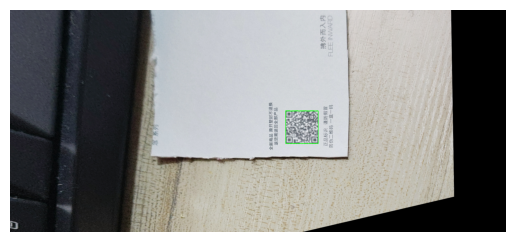

In [6]:
cv2.imwrite("输出.png", warped)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.axis("off")  # 隐藏坐标轴
plt.show()